<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 1 — Introducción con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->
<font color="#7F000E" size=3> Nivel: Ingeniería Biomédica — 7.º ciclo / 4.º año </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Importación, exploración, visualización y exportación de ECG </font><br>
</div>

---

## Objetivos

Al finalizar este laboratorio, el estudiante será capaz de:

1. Acceder a una base de datos de señales fisiológicas de PhysioNet.
2. Cargar un registro ECG mediante la librería `wfdb`.
3. Identificar la frecuencia de muestreo, número de canales, nombres de canales y duración.
4. Construir el eje temporal de una señal discreta.
5. Visualizar una señal ECG mediante diferentes representaciones.
6. Analizar un segmento de la señal.
7. Exportar un segmento ECG a formato `.wav`.
8. Interpretar las diferencias entre una señal biomédica y una señal de audio.
9. Formular observaciones básicas sobre la morfología y amplitud de un ECG.

> **Importante:** el archivo WAV generado es una representación de la señal ECG en un formato reproducible por herramientas de audio. No significa que el ECG sea originalmente una señal acústica.



## 1. Introducción

Las señales biomédicas son señales generadas por procesos fisiológicos. Algunos ejemplos son:

- ECG — electrocardiograma
- EEG — electroencefalograma
- EMG — electromiograma
- EOG — electrooculograma
- PPG — fotopletismografía

En este laboratorio trabajaremos con una señal **ECG real** obtenida de **PhysioNet**.

PhysioNet proporciona acceso a numerosas bases de datos fisiológicas. Una de las bases más conocidas es la **MIT-BIH Arrhythmia Database**, que contiene registros electrocardiográficos anotados.

### Concepto fundamental: DATABASE + RECORD

Un registro no debe identificarse solamente por su número.

Por ejemplo:

```python
DATABASE = "mitdb"
RECORD = "100"
```

significa que estamos solicitando el registro `100` de la base de datos `mitdb`.

El mismo número de registro puede tener un significado diferente si pertenece a otra base de datos. Por ello, siempre debemos interpretar:

```text
BASE DE DATOS + RECORD
```

como la identificación del registro.



## 2. Parámetros configurables

En esta sección el estudiante podrá cambiar los parámetros principales del laboratorio.

### Parámetros

| Parámetro | Descripción | Ejemplo |
|---|---|---|
| `DATABASE` | Base de datos de PhysioNet | `"mitdb"` |
| `RECORD` | Identificador del registro | `"100"` |
| `CHANNEL` | Canal que se desea analizar | `0` |
| `DURATION` | Duración del segmento en segundos | `10` |
| `OUTPUT_WAV` | Nombre del archivo WAV | `"ecg_100.wav"` |

### Pregunta inicial

Antes de ejecutar el código, responda:

**¿Qué cree que representa `CHANNEL = 0`?**

Anote su hipótesis y compruébela después de ejecutar el notebook.


In [13]:

# ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "100"

CHANNEL = 0

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")


Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 0
Duración      : 10 s
Archivo WAV   : ecg_record_100_channel_0.wav



## 3. Instalación de librerías

Utilizaremos:

- **WFDB:** acceso a registros de PhysioNet.
- **NumPy:** procesamiento numérico.
- **Pandas:** organización de datos.
- **Matplotlib:** visualización.
- **SciPy:** exportación de la señal a WAV.


In [14]:
!pip install uv

In [15]:

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib


In [16]:

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")


Librerías importadas correctamente.



## 4. Cargar el registro desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

Usaremos:

```python
record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)
```

El argumento `pn_dir` indica que el registro se obtendrá desde una base de datos disponible en PhysioNet.


In [17]:

# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")


Registro cargado correctamente.



## 5. Explorar la información del registro

Antes de procesar una señal biomédica es necesario conocer sus características.

Algunos parámetros importantes son:

- `fs`: frecuencia de muestreo.
- `sig_len`: número de muestras.
- `n_sig`: número de canales.
- `sig_name`: nombres de los canales.
- `units`: unidades de las señales.


In [20]:

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)


INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 100
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V5']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos



### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo del registro?
360 Hz
2. ¿Cuántos canales tiene?
2
3. ¿Cómo se llama el canal seleccionado?
Canal "MLII"
4. ¿Cuál es la duración total del registro?
1805.56 segundos
5. Si `fs = 360 Hz`, ¿cuántas muestras se adquieren en 1 segundo?
Se adquieren 360 muestras en 1 segundo
6. ¿Cuántas muestras corresponden a un segmento de 10 segundos?
Corresponde a 3600 muestras en 10 segundos


## 6. Identificación del canal

El parámetro:

```python
record.sig_name
```

permite conocer qué señal corresponde a cada canal.

Por ejemplo, conceptualmente:

```text
CHANNEL 0 → primer canal
CHANNEL 1 → segundo canal
...
```

No debemos asumir que todos los registros tienen los mismos canales. Siempre debemos consultar los metadatos del registro.


In [21]:

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")


Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V5 [mV]

Canal seleccionado: 0
Nombre            : MLII



## 7. Extraer la señal ECG

Las muestras de la señal se encuentran en:

```python
record.p_signal
```

Esta estructura contiene:

```text
filas    → muestras
columnas → canales
```

Por tanto:

```python
signal = record.p_signal[:, CHANNEL]
```

selecciona todas las muestras del canal indicado.


In [22]:

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])


Número de muestras: 650000
Canal: MLII
Unidad: mV

Primeras 10 muestras:
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]



## 8. Crear el eje temporal

Una señal digital está formada por muestras.

Si la frecuencia de muestreo es:

\[
f_s
\]

entonces el intervalo entre muestras es:

\[
T_s = \frac{1}{f_s}
\]

y el instante asociado a la muestra `n` es:

\[
t[n] = \frac{n}{f_s}
\]

Esta relación es fundamental para interpretar correctamente una señal biomédica.


In [23]:

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")


Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos



# 9. GRÁFICA 1 — Señal ECG completa

En esta primera visualización observaremos todo el registro.

### Objetivo

Reconocer:

- eje temporal;
- amplitud;
- duración;
- comportamiento general de la señal;
- posibles cambios de morfología.


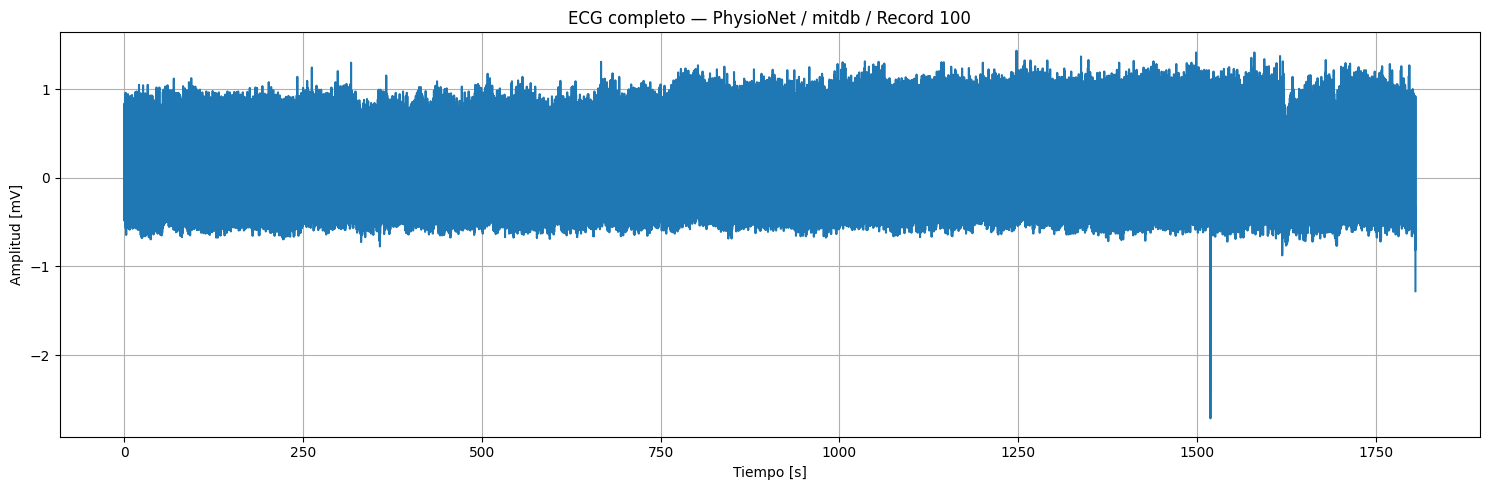

In [24]:

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 2

1. ¿La señal presenta una amplitud constante?
No. La amplitud varía a lo largo de todo el registro. La mayor parte de la señal se mantiene dentro de un rango relativamente estable, pero se observan variaciones y algunos picos positivos y negativos de mayor amplitud.
2. ¿Se pueden identificar visualmente complejos QRS?
En esta gráfica completa no se distinguen claramente los complejos QRS individuales porque el registro abarca aproximadamente 30 minutos y la señal está muy comprimida en el eje temporal. Para identificarlos mejor sería necesario observar un segmento más corto.
3. ¿La morfología permanece igual durante todo el registro?
No completamente. Se observan cambios en el comportamiento general de la señal y algunos eventos con amplitudes diferentes respecto al resto del registro, por lo que la morfología no parece permanecer exactamente igual durante todo el tiempo.
4. ¿Se observa ruido?
Sí. Se observan pequeñas variaciones y algunos eventos abruptos que podrían corresponder a ruido o artefactos. Destaca especialmente una deflexión negativa de gran amplitud alrededor de los 1500 s.
5. ¿Qué ventajas tiene visualizar una señal durante varios minutos?
Permite observar el comportamiento global de la señal, identificar cambios a largo plazo, detectar eventos poco frecuentes y localizar regiones donde ocurren variaciones importantes que después pueden analizarse con mayor detalle.
6. ¿Qué limitaciones tiene una gráfica demasiado extensa?
Una gráfica demasiado extensa comprime la señal en el tiempo y dificulta observar detalles pequeños, como la forma de las ondas P, los complejos QRS y las ondas T. Por ello, resulta útil para observar tendencias generales, pero no para analizar la morfología de cada latido.



# 10. GRÁFICA 2 — Segmento ECG ampliado

Una señal completa puede dificultar el análisis de eventos individuales.

Por ello seleccionaremos solamente los primeros `DURATION` segundos.


In [25]:

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")


Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


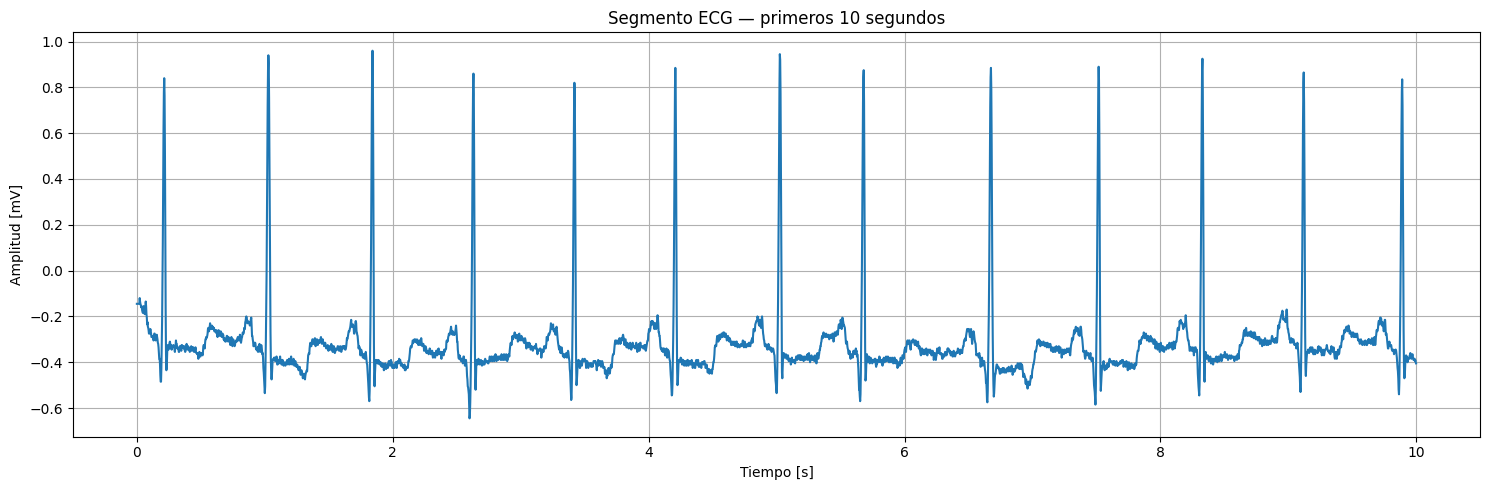

In [26]:

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Actividad

Observe cuidadosamente la gráfica.

Intente identificar:

- onda P;
- complejo QRS;
- onda T;
- intervalo entre complejos QRS;
- posibles artefactos.

> **Nota:** la identificación automática de ondas no forma parte de este laboratorio. Aquí el objetivo es desarrollar una primera capacidad de observación de señales biomédicas.



# 11. GRÁFICA 3 — Histograma de amplitudes

El histograma permite observar cómo se distribuyen los valores de amplitud de la señal.

Podemos utilizarlo para introducir conceptos como:

- media;
- dispersión;
- valores extremos;
- distribución de amplitudes.


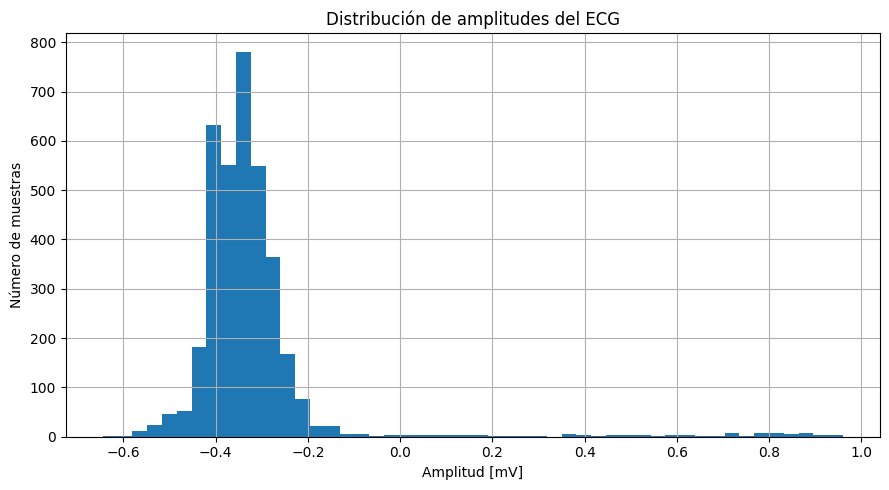

In [27]:

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 3

1. ¿Dónde se concentra la mayor cantidad de muestras?
La mayor cantidad de muestras se concentra aproximadamente entre −0.4 y −0.3 mV, con el mayor pico alrededor de −0.35 mV.
2. ¿La distribución parece simétrica?
No. La distribución es asimétrica, ya que presenta una cola mucho más extensa hacia amplitudes positivas, llegando hasta aproximadamente 1.0 mV, mientras que hacia valores negativos llega cerca de −0.6 mV.
3. ¿Existen valores extremos?
Sí. Se observan valores de amplitud alejados de la zona de mayor concentración, especialmente amplitudes positivas entre aproximadamente 0.4 y 1.0 mV. También existen algunos valores negativos cercanos a −0.6 mV.
4. ¿Qué podría producir valores de amplitud muy diferentes al valor central?
Estos valores pueden estar relacionados con los cambios rápidos de amplitud producidos por los complejos QRS, especialmente los picos R. También podrían aparecer debido a artefactos, movimiento de electrodos, ruido o variaciones de la señal ECG.
5. ¿El histograma conserva información temporal? Explique.
No. El histograma únicamente indica cuántas muestras presentan determinados valores de amplitud, pero no muestra en qué instante ocurrieron ni el orden en que aparecieron. Por lo tanto, permite estudiar la distribución de amplitudes, pero se pierde la información temporal de la señal.



# 12. GRÁFICA 4 — Representación discreta

Una señal digital no solamente puede representarse como una línea continua visualmente.

También podemos observar sus muestras individuales.

Esto permite introducir el concepto:

\[
x[n]
\]

donde `n` representa el índice de muestra.


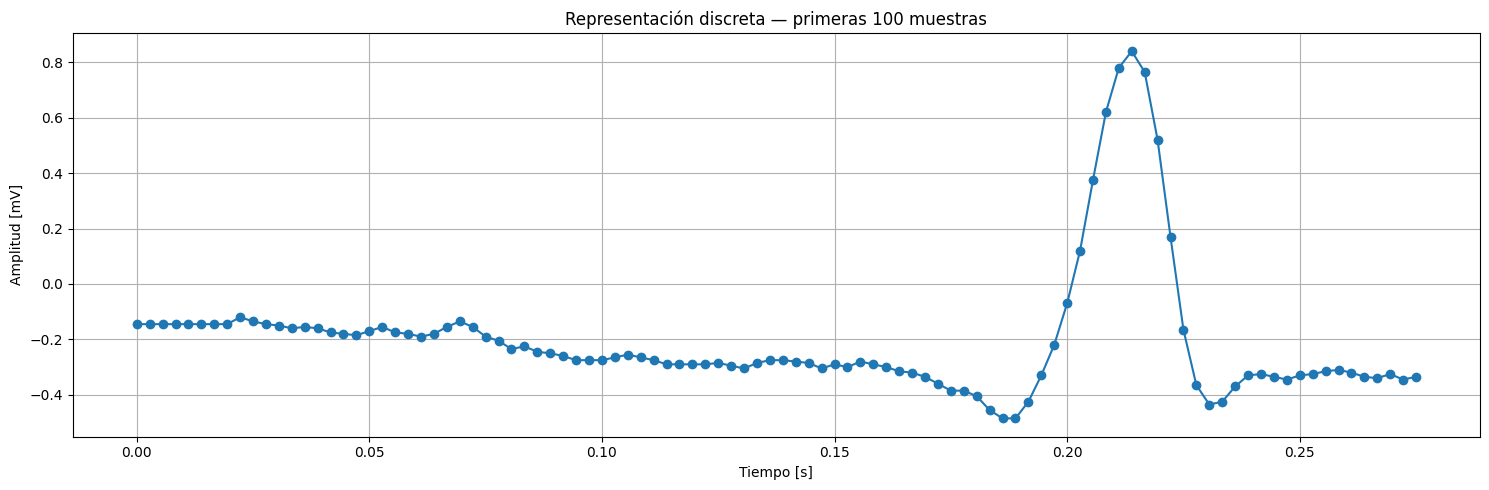

In [28]:

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 4
1. ¿Cuántas muestras existen por segundo?
Como la frecuencia de muestreo es fs = 360 Hz, existen 360 muestras por segundo.
2. ¿Qué ocurre si aumentamos fs?
Al aumentar fs, se toman más muestras por segundo. Esto permite representar la señal con mayor resolución temporal y observar con más detalle cambios rápidos del ECG, aunque también aumenta la cantidad de datos que deben almacenarse y procesarse.
3. ¿Qué ocurre si disminuimos fs?
Al disminuir fs, se toman menos muestras por segundo y se reduce la resolución temporal. Si se disminuye demasiado, pueden perderse detalles importantes de la señal y puede aparecer aliasing, generando una representación incorrecta del ECG.
4. ¿Qué representa el eje n en una señal discreta?
El eje n representa el índice o número de cada muestra de la señal discreta. Por ejemplo, \(x[0]\) es la primera muestra, \(x[1]\) la segunda, y así sucesivamente.
5. ¿Cuál es la relación entre n, fs y t?
La relación entre el índice de muestra, la frecuencia de muestreo y el tiempo es:
$$ t[n]=\frac{n}{f_s} $$
Por lo tanto, cada muestra n corresponde a un instante de tiempo determinado por la frecuencia de muestreo. Para fs = 360 Hz, las muestras están separadas aproximadamente 2.78 ms entre sí.



# 13. Estadística básica de la señal

Antes de exportar la señal calcularemos algunos parámetros básicos.


In [29]:

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")


ESTADÍSTICAS DEL SEGMENTO
Media             : -0.3199
Desviación estándar: 0.1702
Mínimo            : -0.6450
Máximo            : 0.9600
Rango             : 1.6050



# 14. Convertir ECG a archivo WAV

El formato WAV es común en aplicaciones de audio. Sin embargo, nuestra señal es un ECG.

Para poder almacenarla como WAV realizaremos:

```text
ECG original
     ↓
Eliminar componente media
     ↓
Normalizar amplitud
     ↓
Convertir a int16
     ↓
Guardar WAV
```

### ¿Por qué normalizar?

Los valores del ECG están expresados en unidades fisiológicas, mientras que el WAV suele utilizar representaciones enteras, como `int16`.

Utilizaremos el rango:

\[
-32768 \leq x \leq 32767
\]

para `int16`.


In [30]:

# ============================================
# PREPARAR ECG PARA WAV
# ============================================

ecg_for_wav = signal_segment.astype(float).copy()

# 1. Eliminar componente DC
ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

# 2. Normalizar
max_abs = np.max(np.abs(ecg_for_wav))

if max_abs == 0:
    raise ValueError("La señal no puede normalizarse porque todos sus valores son cero.")

ecg_normalized = ecg_for_wav / max_abs

# 3. Convertir a int16
ecg_int16 = np.int16(
    ecg_normalized * 32767
)

print("Conversión preparada correctamente.")
print(f"Tipo original   : {signal_segment.dtype}")
print(f"Tipo WAV        : {ecg_int16.dtype}")
print(f"Mínimo int16    : {ecg_int16.min()}")
print(f"Máximo int16    : {ecg_int16.max()}")


Conversión preparada correctamente.
Tipo original   : float64
Tipo WAV        : int16
Mínimo int16    : -8322
Máximo int16    : 32767



# 15. Guardar el archivo WAV

La frecuencia de muestreo del WAV será la misma frecuencia de muestreo del registro ECG.

Esto es importante porque permite conservar la separación temporal entre las muestras.


In [31]:

# ============================================
# GUARDAR WAV
# ============================================

wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print(f"Archivo WAV generado correctamente:")
print(OUTPUT_WAV)


Archivo WAV generado correctamente:
ecg_record_100_channel_0.wav



# 16. Reproducir el archivo WAV

En Google Colab/Jupyter podemos utilizar un reproductor integrado.


In [32]:

# Reproducir el archivo WAV

display(
    Audio(
        OUTPUT_WAV,
        rate=int(fs)
    )
)



### Preguntas de análisis 5

1. ¿Puede escuchar claramente la señal?
No, se escucha muy bajo
2. ¿El sonido corresponde a un sonido fisiológico real?
Si, se escucha un latido cardíaco pero tan claro o fuerte
3. ¿Por qué un ECG puede convertirse a WAV?
Un ECG puede convertirse a WAV porque ambos pueden representarse digitalmente como una secuencia de muestras numéricas. En el laboratorio, las muestras del ECG se normalizan y se convierten a formato int16 para poder almacenarlas en un archivo WAV, manteniendo además la frecuencia de muestreo.
Sin embargo, esto no significa que el ECG sea una señal de audio; sigue siendo una señal bioeléctrica, solo almacenada en un formato que también se usa para sonido.
4. ¿Qué información se conserva al hacer la conversión?
Se conserva principalmente el orden temporal de las muestras, la forma relativa de la señal y la separación temporal entre muestras, ya que se mantiene la frecuencia de muestreo original. También se mantienen las variaciones relativas de amplitud. Sin embargo, al normalizar la señal ya no se conserva directamente su amplitud física original en mV.
5. ¿Qué información fisiológica podría perderse al escucharla?
Al escuchar el ECG es difícil identificar directamente características importantes como las ondas P, los complejos QRS, las ondas T, sus amplitudes y los intervalos temporales entre ellas. Además, debido a la normalización utilizada para crear el WAV, se pierde la escala original de amplitud expresada en mV.
6. ¿Qué diferencia existe entre representar un ECG gráficamente y reproducirlo como audio?
La representación gráfica permite observar directamente la relación entre tiempo y amplitud, facilitando la identificación de ondas, complejos QRS y cambios en la morfología del ECG. En cambio, al reproducirlo como audio estas variaciones se perciben auditivamente, pero resulta más difícil determinar sus amplitudes, formas e intervalos de manera precisa.


# 17. Descargar el archivo WAV

En Google Colab se puede descargar el archivo generado.


In [33]:

# ============================================
# DESCARGAR WAV EN GOOGLE COLAB
# ============================================

try:
    from google.colab import files
    files.download(OUTPUT_WAV)
except ImportError:
    print("Este entorno no es Google Colab.")
    print(f"El archivo está disponible localmente como: {OUTPUT_WAV}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# 18. Ejercicios propuestos

## Ejercicio 1 — Cambiar de registro

Modifique:

```python
RECORD = "100"
```

por otro registro válido de la misma base de datos.

Compare:

- frecuencia de muestreo;
- número de canales;
- nombres de canales;
- morfología;
- amplitud;
- distribución.

### Entregable

Incluya una captura o las cuatro gráficas del nuevo registro y escriba una comparación con el registro original.


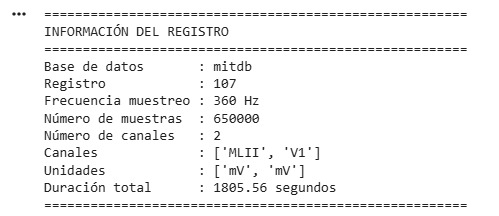

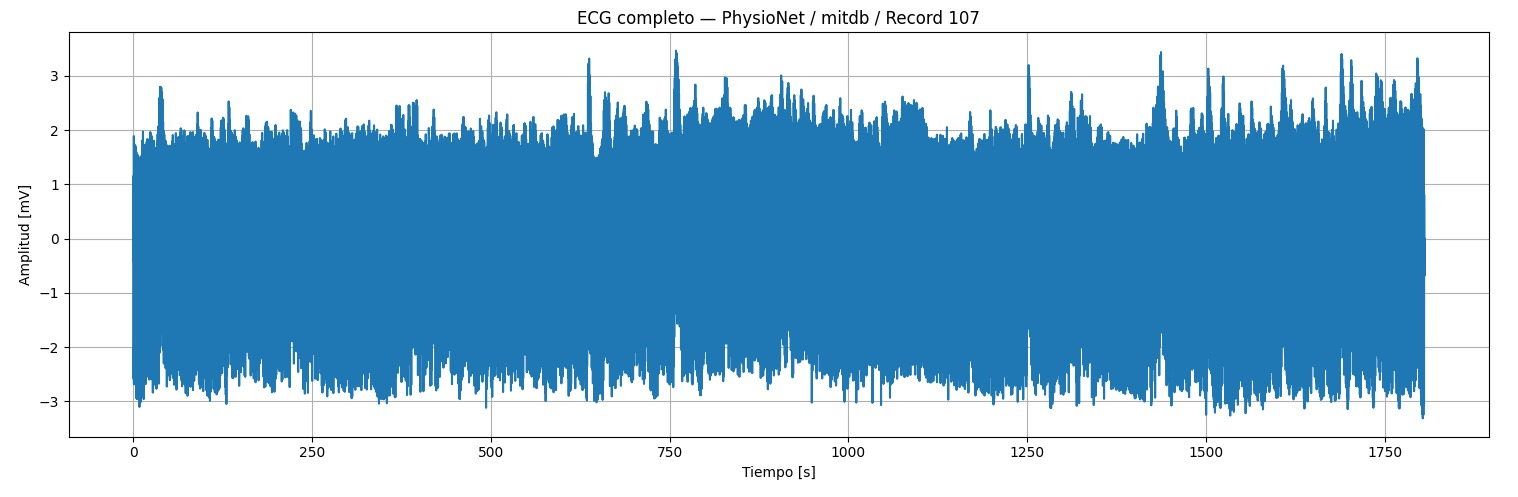

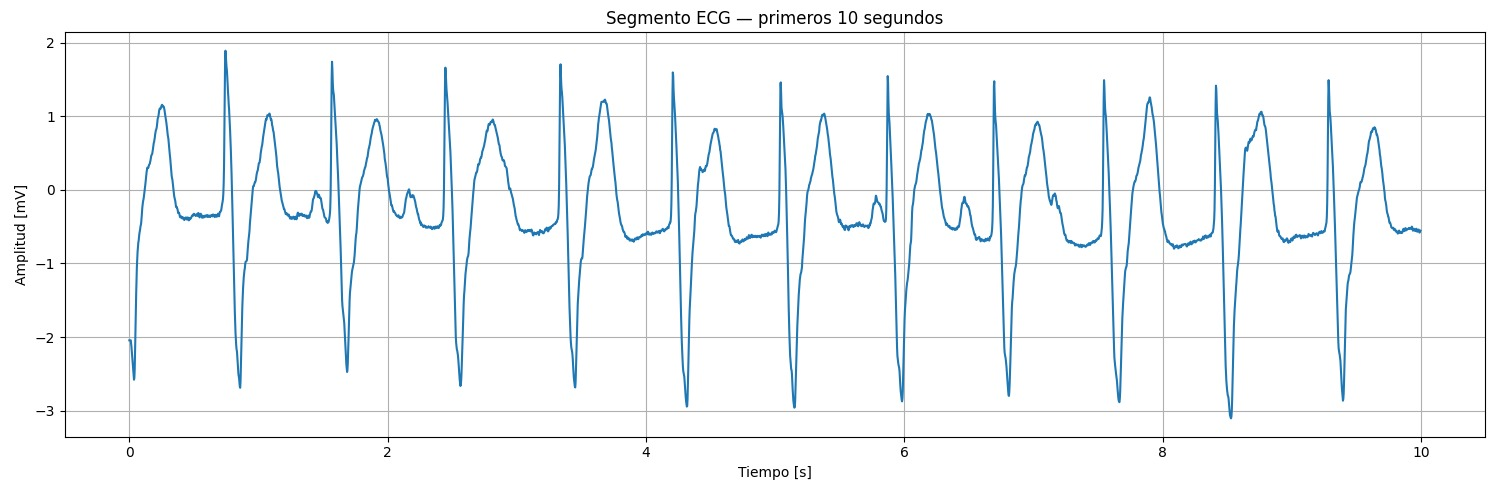

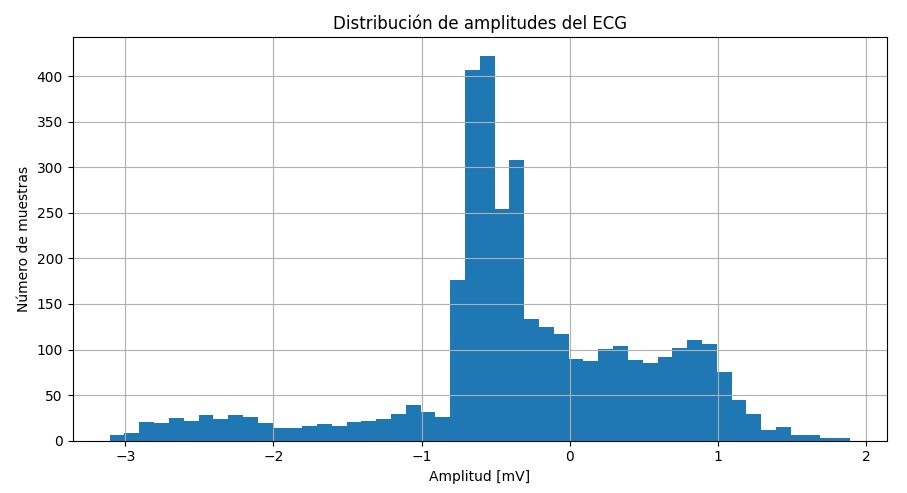

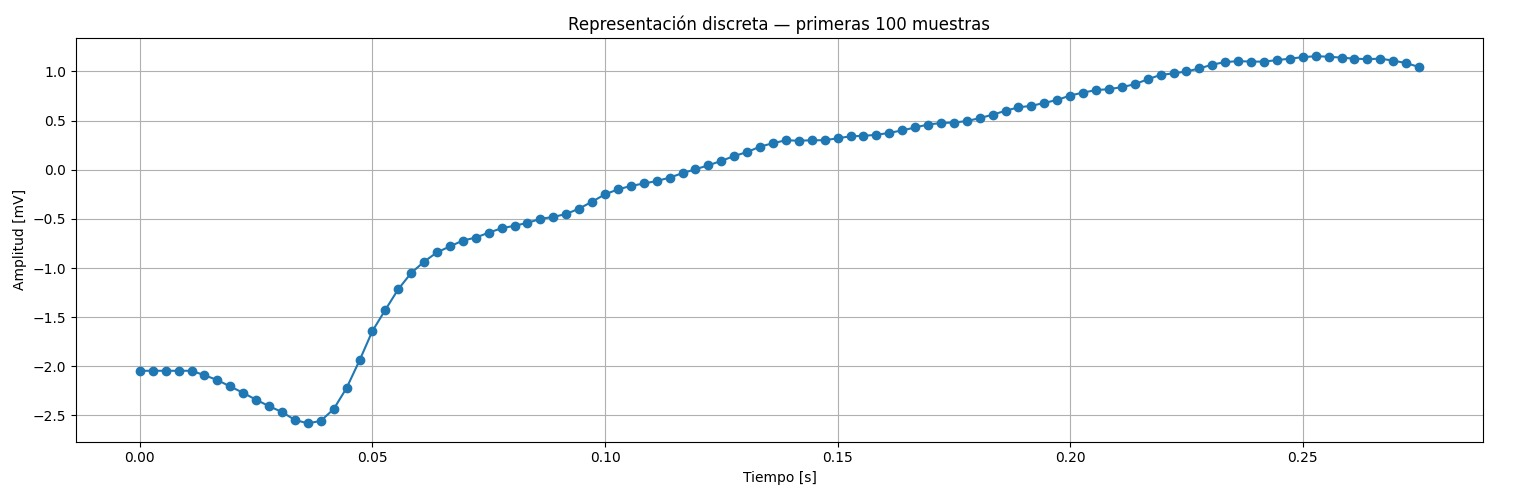

Al cambiar únicamente el registro de 100 a 107, se observa que ambos mantienen la misma frecuencia de muestreo de 360 Hz y una duración total aproximada de 1805.56 s. Sin embargo, la forma de la señal cambia de manera importante.

En el Record 100, los primeros 10 segundos muestran complejos QRS relativamente regulares, estrechos y repetitivos, con amplitudes máximas cercanas a 1 mV y valores mínimos alrededor de −0.6 mV en ese segmento. La señal se concentra principalmente alrededor de valores negativos cercanos a −0.3 y −0.4 mV.

En el Record 107, la señal presenta una morfología diferente y una variación de amplitud mucho mayor. En los primeros 10 segundos se observan picos positivos cercanos a 1.9 mV y deflexiones negativas que alcanzan aproximadamente −3.1 mV. Además, los complejos son más amplios y presentan cambios más pronunciados entre sus máximos y mínimos.

La diferencia también se observa en los histogramas. El Record 100 presenta una distribución de amplitudes más concentrada, principalmente entre aproximadamente −0.4 y −0.3 mV, mientras que en el Record 107 la distribución es mucho más amplia, extendiéndose aproximadamente desde −3 mV hasta 2 mV.

En conclusión, aunque ambos registros fueron adquiridos con la misma frecuencia de muestreo y se analizaron durante el mismo intervalo de 10 segundos, el Record 107 presenta una mayor variabilidad de amplitud y una morfología claramente distinta al Record 100, mostrando que diferentes registros de una misma base de datos pueden tener características electrocardiográficas muy diferentes.

---

## Ejercicio 2 — Cambiar de canal

Modifique:

```python
CHANNEL = 0
```

por otro canal disponible.

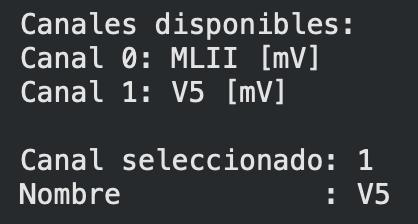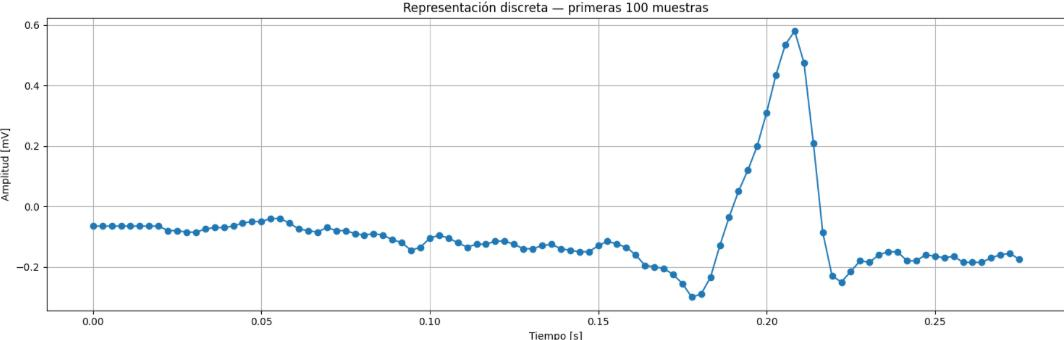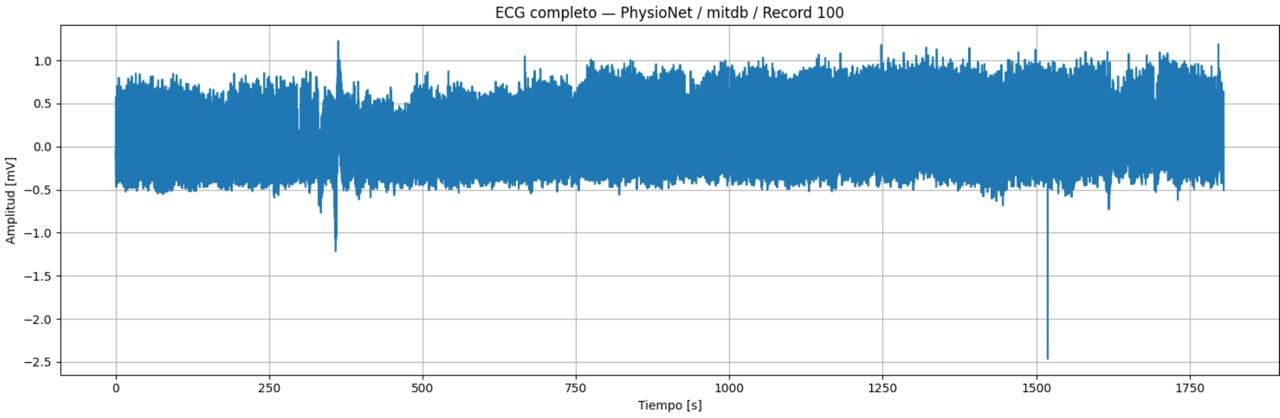

Responda:

1. ¿Qué nombre tiene el nuevo canal?
El nuevo canal seleccionado es V5 correspondiente al CHANNEL =1
2. ¿Tiene las mismas unidades?
Si, tanto el canal original MLII como el nuevo canal V5 estan expresados en milivoltios(mV)
3. ¿La morfología es igual?
No, la morfología no es exactamente igual aunque en ambos canales se observan complejos QRS repetitivos, la forma de las ondas cambia porque cada derivación registra la actividad eléctrica del corazón desde una orientación diferente
4. ¿Qué diferencias observa?
En el canal V5 los complejos QRS presentan una amplitud positiva menor que en MLII, con picos cercanos a 0.6 y 0.8 mV, mientras que en el canal MLII los picos alcanzaban aporixamadamente 0.8 y 1.0 mV. Además, en V5 la señal se concentra alrededor de valores cercanos a -0.2 mV, mientras que en el MLII la linea de base estaba más próxima a -0.3 a -0.4 mV. También se observan diferencias en la forma posterior del pico principal, con deflexiones negativas más visibles en V5. Esto confirma que, aunque ambos canales registran el mismo ciclo cardíaco, la amplitud y la forma del ECG  dependen de la derivación utilizada.
---

## Ejercicio 3 — Cambiar la duración

Pruebe:

```python
DURATION = 5
```

```python
DURATION = 20
```

y compare las visualizaciones.

Explique por qué una duración demasiado pequeña o demasiado grande puede dificultar el análisis.

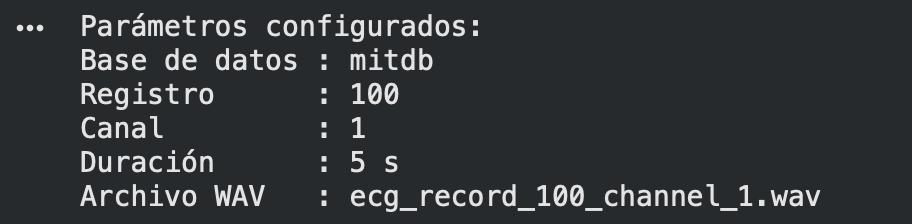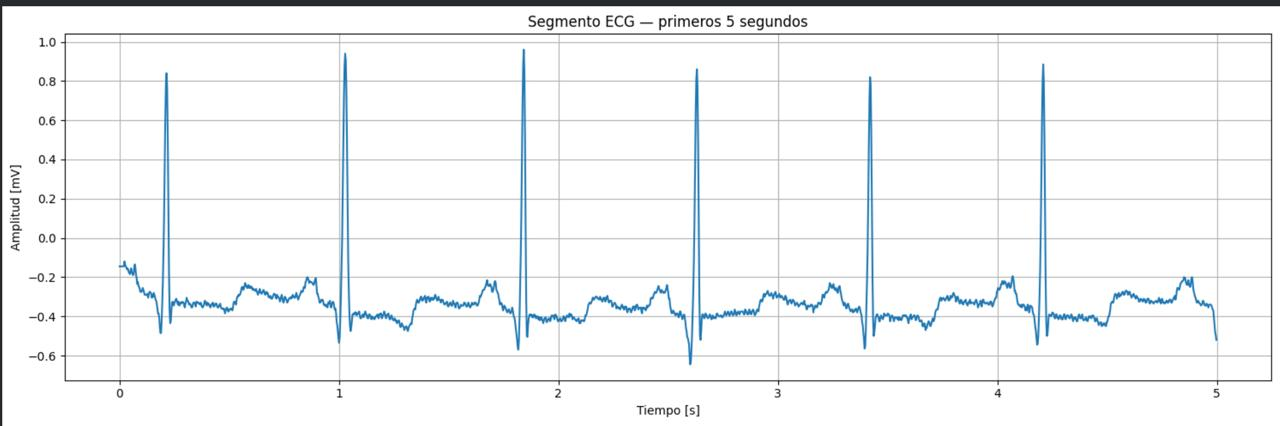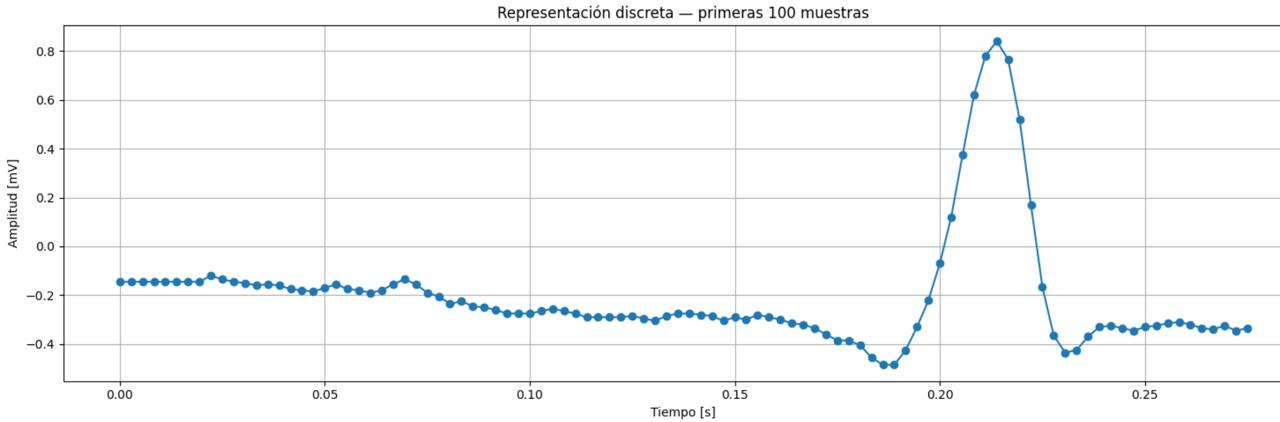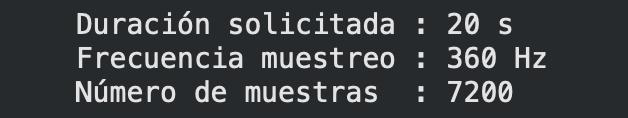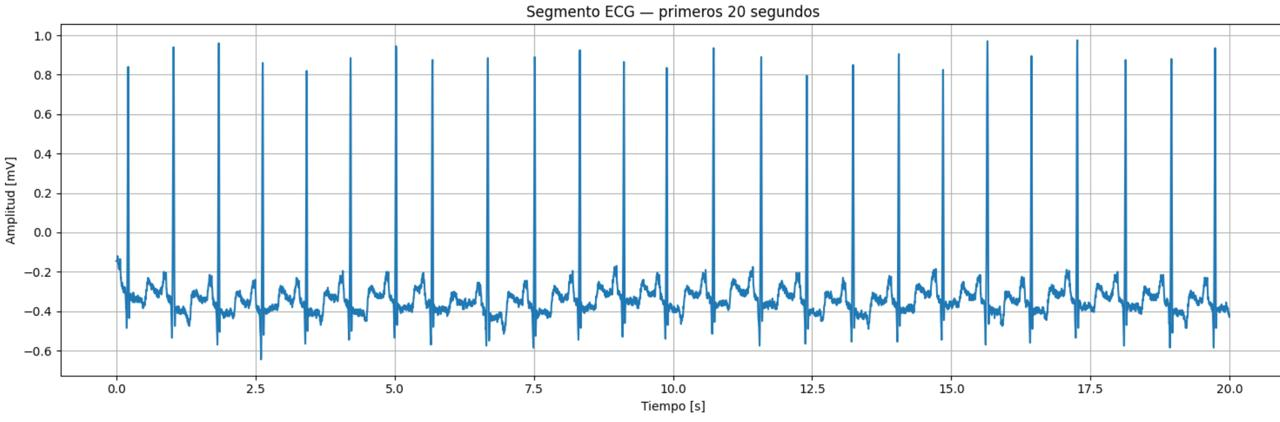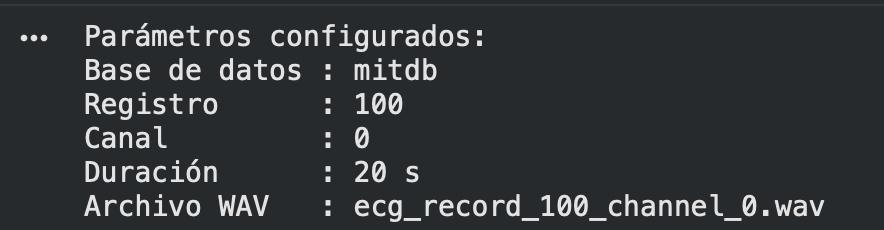

Comparación entre DURATION = 5 y DURATION = 20
Con una duración de 5 segundos, la señal contiene:
$$ N = 360 \times 5 = 1800 \text{ muestras} $$
En esta visualización se observan aproximadamente 6 complejos QRS, y cada uno se distingue con mayor claridad. Al mostrar un intervalo corto, la morfología de cada latido es más fácil de analizar, incluyendo los cambios de amplitud antes y después de los picos principales.
En cambio, con una duración de 20 segundos, la señal contiene:
$$ N = 360 \times 20 = 7200 \text{ muestras} $$
En esta gráfica se observa una cantidad mucho mayor de complejos QRS, aproximadamente 24–25 latidos, lo cual permite analizar mejor la regularidad y el comportamiento general de la señal durante un intervalo más largo. Sin embargo, al incluir más información en el mismo espacio gráfico, cada complejo aparece más comprimido y resulta más difícil observar detalles pequeños de su morfología.
Por lo tanto, una duración demasiado pequeña puede dificultar el análisis porque contiene pocos ciclos cardíacos y podría no mostrar variaciones o eventos que ocurran con poca frecuencia. Por otro lado, una duración demasiado grande puede dificultar el análisis detallado porque la señal se comprime temporalmente y las ondas individuales se vuelven menos fáciles de distinguir.
En conclusión, una ventana corta es más conveniente para estudiar la morfología de cada latido, mientras que una ventana más larga es más útil para evaluar la regularidad y el comportamiento general del ECG.



## Ejercicio 4 — Frecuencia de muestreo

Suponga que:

\[
f_s = 360\ Hz
\]

a) Calcule el periodo de muestreo
$$ T_s=\frac{1}{f_s} $$
Con:
$$ f_s=360\ Hz $$
Entonces:
$$ T_s=\frac{1}{360}=0.00278\ s $$
Por lo tanto:
$$ \boxed{T_s \approx 2.78\ ms} $$
Esto significa que se toma una muestra aproximadamente cada 2.78 ms.
b) ¿Cuántas muestras existen en 5 segundos?
$$ N=f_s\cdot t $$ $$ N=360\cdot5 $$ $$ \boxed{N=1800\ muestras} $$
c) ¿Cuántas muestras existen en 10 segundos?
$$ N=360\cdot10 $$ $$ \boxed{N=3600\ muestras} $$
d) Explique qué sucedería si la frecuencia de muestreo fuese reducida significativamente.
Si la frecuencia de muestreo se reduce significativamente, se tomarían menos muestras por segundo y la señal tendría una menor resolución temporal. Esto podría hacer que se pierdan detalles rápidos del ECG, especialmente cambios bruscos como los asociados al complejo QRS.
Si la frecuencia de muestreo disminuye demasiado, también podría producirse aliasing, es decir, una representación incorrecta de las componentes de frecuencia de la señal. Por ello, una frecuencia de muestreo adecuada es importante para conservar correctamente la información del ECG.

---

## Ejercicio 5 — Análisis de amplitud

Utilizando el segmento seleccionado:

1. Calcule la media.
2. Calcule la desviación estándar.
3. Determine el máximo.
4. Determine el mínimo.
5. Calcule el rango.

Explique qué información proporciona cada parámetro.


In [ ]:
mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)
range_value = max_value - min_value
print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")

Media:
$$ \boxed{-0.3192\ \text{mV}} $$

La media representa el valor promedio de amplitud del segmento analizado. En este caso, el valor negativo indica que la señal se encuentra centrada alrededor de aproximadamente −0.32 mV.

Desviación estándar:

$$ \boxed{0.1685\ \text{mV}} $$

La desviación estándar indica cuánto se dispersan las muestras respecto a la media. Un valor de 0.1685 mV muestra que la mayor parte de las amplitudes se mantiene relativamente cerca del valor promedio, aunque existen picos asociados a los complejos del ECG.

Máximo:

$$ \boxed{0.9750\ \text{mV}} $$

El máximo corresponde a la mayor amplitud positiva observada en el segmento. Este valor puede estar relacionado con los picos positivos de los complejos QRS.

Mínimo:

$$ \boxed{-0.6450\ \text{mV}} $$

El mínimo corresponde a la mayor deflexión negativa registrada durante el segmento.

Rango:

$$ \boxed{1.6200\ \text{mV}} $$

El rango se calcula como:

$$ Rango = Máximo - Mínimo $$
$$ Rango = 0.9750 - (-0.6450) $$
$$ \boxed{Rango = 1.6200\ \text{mV}} $$

El rango representa la diferencia total entre la amplitud máxima y mínima de la señal, por lo que permite conocer la extensión completa de amplitudes presentes en el segmento analizado.


# 19. Preguntas conceptuales

Responda con sus propias palabras.

###1. ¿Qué es PhysioNet?

PhysioNet es una plataforma que permite acceder a bases de datos de señales fisiológicas reales, como ECG, EEG, presión arterial o respiración. Se utiliza mucho en investigación y en procesamiento de señales biomédicas.

###2. ¿Qué diferencia existe entre DATABASE y RECORD?

DATABASE indica de qué base de datos de PhysioNet se obtendrá la señal, mientras que RECORD identifica un registro específico dentro de esa base de datos.

### 3. ¿Qué representa fs?
fs representa la frecuencia de muestreo de la señal. Indica cuántas muestras se adquieren por segundo.
En este laboratorio:
$$ f_s = 360\ Hz $$
por lo tanto, se obtienen 360 muestras por segundo.
### 4. ¿Qué representa CHANNEL?
CHANNEL indica cuál de los canales disponibles del registro se desea analizar. Como Python empieza a contar desde cero, CHANNEL = 0 representa el primer canal y CHANNEL = 1 el segundo.
###5. ¿Qué representa record.p_signal?
record.p_signal contiene las muestras físicas de las señales registradas. Está organizado como una matriz donde las filas corresponden a las muestras y las columnas a los diferentes canales.

### 6. ¿Por qué necesitamos construir un eje temporal?
Porque inicialmente la señal está representada como una secuencia de muestras. El eje temporal permite relacionar cada muestra con el instante en el que fue adquirida.
La relación es:
$$ t[n]=\frac{n}{f_s} $$
Así podemos representar correctamente la señal en función del tiempo.
### 7. ¿Qué diferencia existe entre una señal continua y una señal discreta?
Una señal continua está definida para cualquier instante de tiempo, mientras que una señal discreta está formada únicamente por valores tomados en instantes específicos.
En este caso, la actividad eléctrica del corazón es originalmente una señal continua, pero al ser muestreada se convierte en una señal discreta que puede procesarse digitalmente.
### 8. ¿Por qué no debemos interpretar directamente un archivo WAV como si fuera una señal ECG?
Porque WAV es solamente un formato utilizado para almacenar muestras digitales. Aunque el ECG pueda guardarse como WAV, la señal sigue representando actividad eléctrica del corazón y no una señal acústica.
Por lo tanto, escuchar el archivo no equivale a escuchar directamente un sonido fisiológico del corazón.
### 9. ¿Qué ventajas ofrece trabajar con señales biomédicas reales en lugar de señales sintéticas?
Las señales reales permiten observar situaciones que también ocurren en aplicaciones clínicas, como ruido, artefactos, variaciones de amplitud, diferencias entre latidos y cambios de morfología.
Esto permite practicar el procesamiento de señales en condiciones más parecidas a las que se encontrarían en un entorno biomédico real.
### 10. ¿Qué dificultades encontró durante el laboratorio?
Una de las principales dificultades fue comprender cómo se organiza la información dentro de PhysioNet, especialmente la diferencia entre la base de datos, el registro y los distintos canales. También fue necesario comprender mejor la relación entre frecuencia de muestreo, número de muestras y tiempo, además de interpretar correctamente las diferentes gráficas obtenidas.



# 20. Reto final

Seleccione un registro diferente y realice el siguiente análisis:

```text
PhysioNet
   ↓
Seleccionar RECORD
   ↓
Identificar canales
   ↓
Seleccionar canal ECG
   ↓
Analizar 10 segundos
   ↓
Gráfica ECG
   ↓
Histograma
   ↓
Representación discreta
   ↓
Estadística
   ↓
Exportar WAV
```

### Informe

Presente:

1. Identificación de la base de datos.
2. Identificación del registro.
3. Frecuencia de muestreo.
4. Canal seleccionado.
5. Duración analizada.
6. Las 4 gráficas.
7. Estadísticas.
8. Archivo WAV.
9. Interpretación de los resultados.
10. Conclusiones.


In [34]:
DATABASE = "mitdb"
RECORD = "101"
CHANNEL = 0
DURATION = 10

# 20. Reto final
## Análisis de un nuevo registro ECG

In [35]:
DATABASE = "mitdb"
RECORD = "101"
CHANNEL = 0
DURATION = 10

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

In [36]:
record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

fs = record.fs

print("Registro cargado correctamente.")

Registro cargado correctamente.


In [37]:
print("INFORMACIÓN DEL REGISTRO")
print("=" * 45)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs
print(f"Duración total      : {duration_total:.2f} s")

INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 101
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V1']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 s


## 1. Identificación de la base de datos

Se utilizó la base de datos **MIT-BIH Arrhythmia Database**, identificada en PhysioNet como `mitdb`.

## 2. Identificación del registro

Se seleccionó el registro **101**.

## 3. Frecuencia de muestreo

La frecuencia de muestreo obtenida fue de **360 Hz**.

## 4. Canal seleccionado

Se seleccionó el canal **MLII**, correspondiente a `CHANNEL = 0`.

## 5. Duración analizada

Se analizaron los primeros **10 segundos** del registro.

In [38]:
signal = record.p_signal[:, CHANNEL]
t = np.arange(len(signal)) / fs

### Gráfica 1. ECG completo

La gráfica permite observar el comportamiento general de la señal ECG durante todo el registro y localizar posibles cambios de amplitud o morfología.

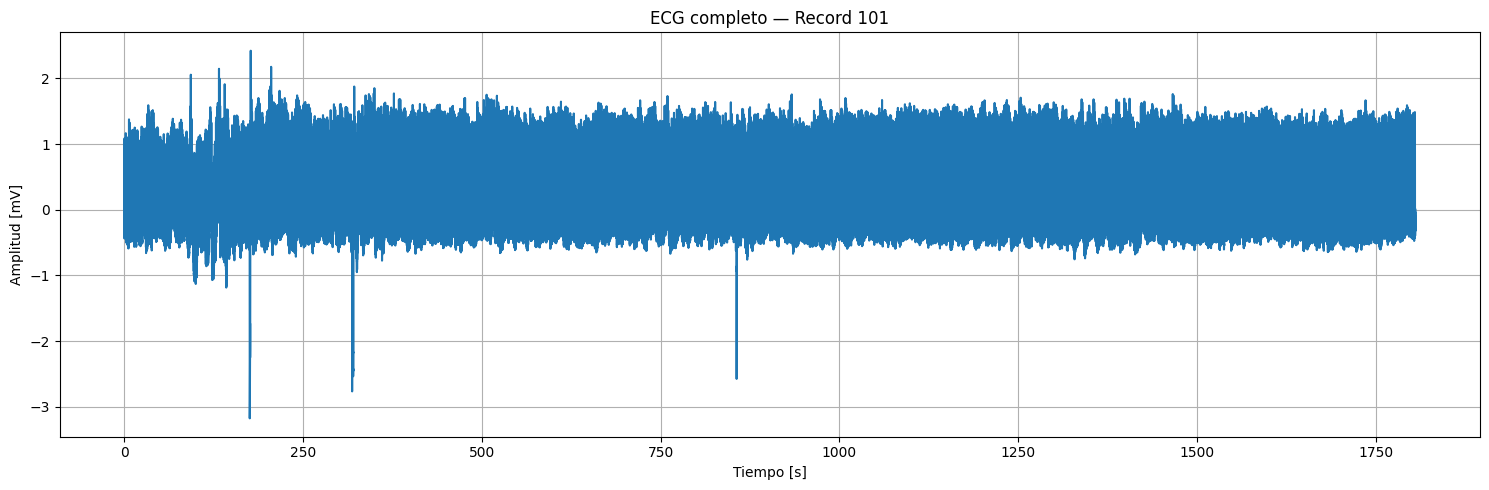

In [39]:
plt.figure(figsize=(15,5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(f"ECG completo — Record {RECORD}")

plt.grid(True)
plt.tight_layout()
plt.show()

### Gráfica 2. Segmento de 10 segundos

El segmento ampliado permite observar con mayor claridad la morfología de los complejos cardíacos y las variaciones de amplitud entre los diferentes latidos.

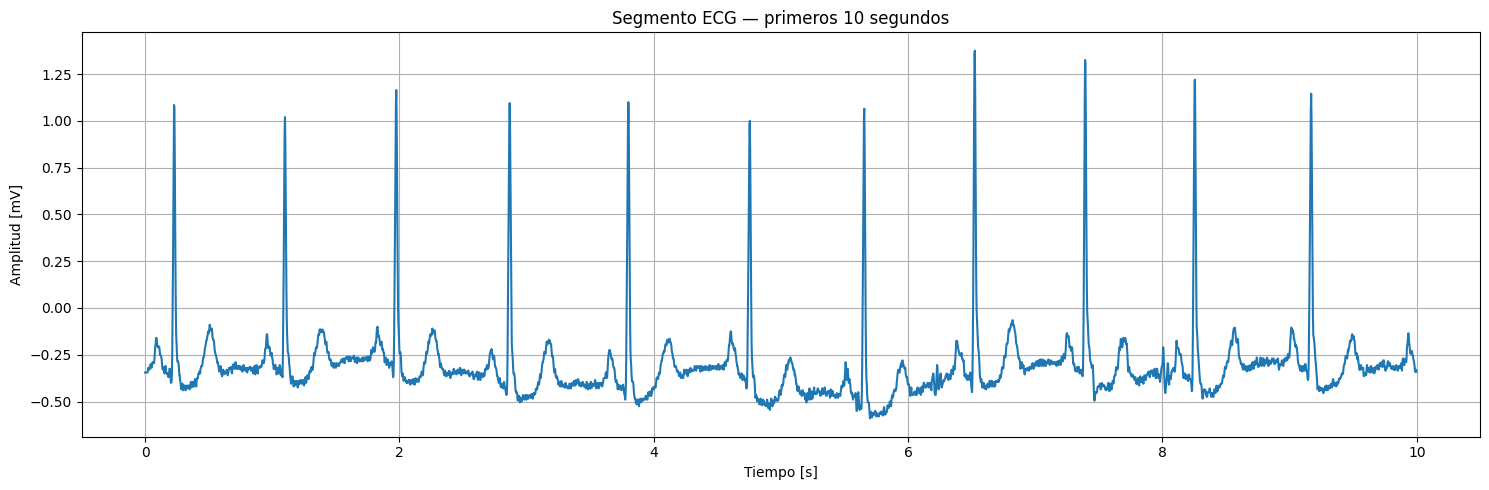

In [40]:
N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

plt.figure(figsize=(15,5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title("Segmento ECG — primeros 10 segundos")

plt.grid(True)
plt.tight_layout()
plt.show()

### Gráfica 3. Histograma de amplitudes

El histograma permite analizar cómo se distribuyen los valores de amplitud de la señal. La región con mayor frecuencia representa los valores de amplitud que aparecen durante mayor parte del segmento.

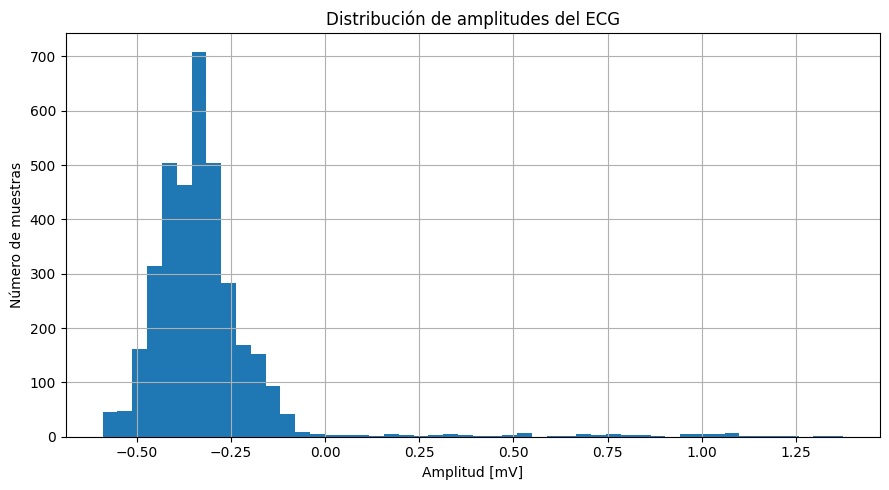

In [41]:
plt.figure(figsize=(9,5))

plt.hist(signal_segment, bins=50)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()

### Gráfica 4. Representación discreta

Esta representación permite observar las muestras individuales que conforman la señal digital. Cada punto corresponde a una muestra adquirida según la frecuencia de muestreo del registro.

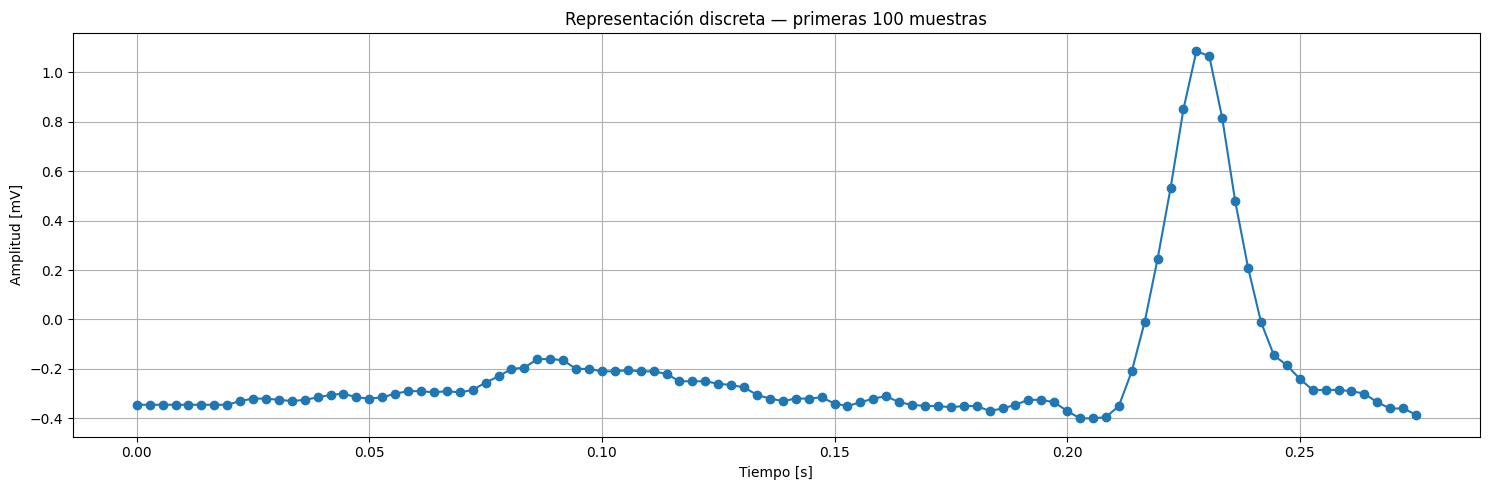

In [42]:
N_SAMPLES = 100

plt.figure(figsize=(15,5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title("Representación discreta — primeras 100 muestras")

plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)
range_value = max_value - min_value

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media                : {mean_value:.4f}")
print(f"Desviación estándar  : {std_value:.4f}")
print(f"Mínimo               : {min_value:.4f}")
print(f"Máximo               : {max_value:.4f}")
print(f"Rango                 : {range_value:.4f}")

ESTADÍSTICAS DEL SEGMENTO
Media                : -0.3120
Desviación estándar  : 0.1992
Mínimo               : -0.5900
Máximo               : 1.3750
Rango                 : 1.9650


## 7. Estadísticas

- **Media:** -0.3120 mV
- **Desviación estándar:** 0.1992 mV
- **Mínimo:** -0.5900 mV
- **Máximo:** 1.3750 mV
- **Rango:** 1.9650 mV

La media de −0.3120 mV indica que las amplitudes del segmento se encuentran centradas alrededor de un valor ligeramente negativo. La desviación estándar de 0.1992 mV refleja la dispersión de las muestras respecto al promedio. El máximo de 1.3750 mV corresponde a la mayor deflexión positiva, mientras que el mínimo de −0.5900 mV representa la mayor deflexión negativa. La diferencia entre ambos valores genera un rango de 1.9650 mV, que representa la extensión total de amplitudes presentes durante los 10 segundos analizados.

## 8. Archivo WAV

Se generó el archivo:

`ecg_record_101_channel_0.wav`

La conversión permite almacenar las muestras del ECG en formato WAV manteniendo la frecuencia de muestreo. Sin embargo, esto no significa que el ECG sea originalmente una señal acústica.

In [44]:
ecg_for_wav = signal_segment.astype(float).copy()

# Eliminar componente media
ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

# Normalizar
max_abs = np.max(np.abs(ecg_for_wav))
ecg_normalized = ecg_for_wav / max_abs

# Convertir a int16
ecg_int16 = np.int16(ecg_normalized * 32767)

# Guardar
wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print(f"Archivo generado: {OUTPUT_WAV}")

Archivo generado: ecg_record_101_channel_0.wav


In [45]:
display(
    Audio(
        OUTPUT_WAV,
        rate=int(fs)
    )
)

## 9. Interpretación de los resultados

El registro analizado corresponde a una señal ECG real obtenida de PhysioNet. La gráfica completa permitió observar el comportamiento general de la señal, mientras que el segmento de 10 segundos facilitó el análisis de la morfología de los complejos cardíacos.

En el segmento seleccionado se observaron variaciones periódicas de amplitud asociadas a los ciclos cardíacos. El histograma mostró que la mayor cantidad de muestras se concentra alrededor de determinados valores de amplitud, mientras que los valores extremos aparecen con menor frecuencia.

La representación de las primeras 100 muestras permitió observar claramente el carácter discreto de la señal, evidenciando que el ECG digital está compuesto por valores individuales separados temporalmente según la frecuencia de muestreo.

Finalmente, las estadísticas permitieron cuantificar el comportamiento de la amplitud mediante la media, desviación estándar, mínimo, máximo y rango.

## 10. Conclusiones

El desarrollo del laboratorio permitió comprender que una señal ECG puede analizarse desde diferentes perspectivas. La representación temporal permite estudiar cómo cambia la amplitud a lo largo del tiempo y observar la morfología de los complejos cardíacos.

El histograma permite analizar la distribución de las amplitudes, mientras que la representación de las muestras individuales evidencia que el ECG procesado digitalmente corresponde a una señal discreta \(x[n]\).

También se comprobó la importancia de la frecuencia de muestreo, ya que esta determina la cantidad de muestras adquiridas por segundo y permite establecer la relación entre el índice de muestra y el tiempo.

Finalmente, el análisis realizado constituye una base para aplicar posteriormente técnicas de procesamiento digital de señales, como filtros FIR e IIR, análisis de respuesta en frecuencia y Transformada Z.


# 21. Conclusiones esperadas

Al finalizar el laboratorio, el estudiante debería comprender que una señal biomédica puede estudiarse desde diferentes perspectivas:

```text
              SEÑAL ECG
                  │
       ┌──────────┼──────────┐
       ↓          ↓          ↓
     Tiempo    Amplitud   Distribución
       │          │          │
       └──────────┼──────────┘
                  ↓
          Señal discreta x[n]
                  ↓
          Procesamiento digital
                  ↓
        Filtros FIR / IIR
                  ↓
         Análisis de señales
```

Este laboratorio constituye la base para los siguientes laboratorios, donde se aplicarán técnicas de **procesamiento digital de señales**, incluyendo filtros FIR, filtros IIR, respuesta en frecuencia y Transformada Z.



# Referencias

- PhysioNet — plataforma de acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas Python para lectura y procesamiento de registros fisiológicos.
- MIT-BIH Arrhythmia Database — base de datos utilizada como ejemplo en este laboratorio.

**Nota:** consulte siempre la documentación oficial de la base de datos seleccionada para conocer el significado de sus registros, canales y anotaciones.
